In [35]:
import tensorflow as tf 
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
train_dir = r'C:\Users\POOJA\Downloads\datascience\deep_learnig\cnn\tomato\train'
val_dir = r'C:\Users\POOJA\Downloads\datascience\deep_learnig\cnn\tomato\val'

In [3]:
img_ht = 128
img_wid = 128
batch_size = 32

train_data = tf.keras.utils.image_dataset_from_directory(train_dir, image_size = (img_ht, img_wid), batch_size = batch_size,shuffle = True) # shuffle = True : Randomly mix the training images before training.
# We want it to learn what makes an image a cat or dog, not where the image appears in the dataset.
val_data = tf.keras.utils.image_dataset_from_directory(val_dir, image_size = (img_ht, img_wid), batch_size = batch_size, shuffle= True)

Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.


In [4]:
class_names = train_data.class_names
print(class_names)

['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


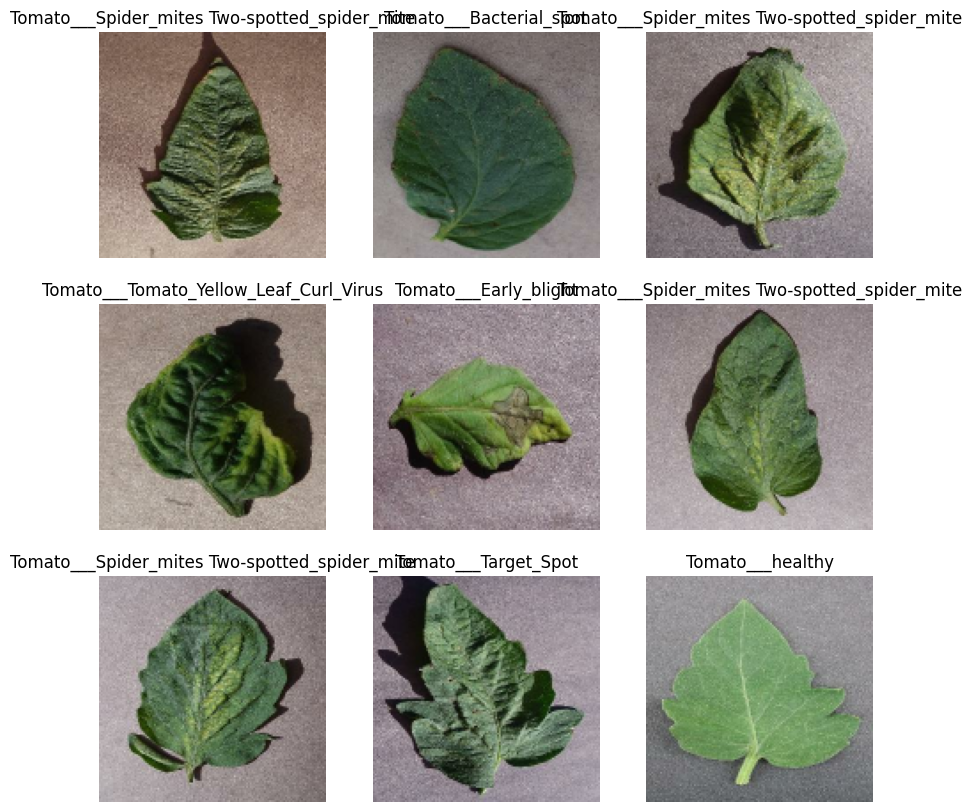

In [8]:
plt.figure(figsize = (10,10))
for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')

In [21]:
print(labels)

tf.Tensor([5 0 5 7 1 5 5 6 9 3 3 4 6 0 1 0 7 3 1 1 7 1 2 7 6 5 0 0 3 8 9 0], shape=(32,), dtype=int32)


In [18]:
num_classess = 10

model = models.Sequential([
    layers.Rescaling(1./255, input_shape = (img_ht, img_wid, 3)), # normalizing
    layers.Conv2D(32, 3, padding = 'same', activation = 'relu'), # 32 - the model from 32 features.
    layers.MaxPooling2D(), layers.Conv2D(64, 3, padding = 'same', activation = 'relu'), layers.MaxPooling2D(), 
    layers.Conv2D(64, 3, padding = 'same', activation = 'relu'),layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding = 'same', activation = 'relu'), # this dense is the fully connected layer
    layers.MaxPooling2D(),layers.Flatten(), layers.Dense(128, activation = 'relu'), layers.Dropout(0.5), layers.Dense(num_classess,activation = 'softmax')]) # this is the output layer, so using softmax

c:\Users\POOJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
# compile
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,180,170 (4.50 MB)

 Trainable params: 1,180,170 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
epochs = 10
history = model.fit(train_data, validation_data = val_data, epochs = epochs)

c:\Users\POOJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 309ms/step - accuracy: 0.3041 - loss: 1.8896 - val_accuracy: 0.6170 - val_loss: 1.1443
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 220ms/step - accuracy: 0.6308 - loss: 1.0663 - val_accuracy: 0.7410 - val_loss: 0.7532
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 225ms/step - accuracy: 0.7218 - loss: 0.8078 - val_accuracy: 0.7950 - val_loss: 0.6428
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 248ms/step - accuracy: 0.7557 - loss: 0.6984 - val_accuracy: 0.8160 - val_loss: 0.5672
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.7974 - loss: 0.5779 - val_accuracy: 0.8290 - val_loss: 0.5235
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 251ms/step - accuracy: 0.8261 - loss: 0.4945 - val_accuracy: 0.8400 - val_loss: 0.5114
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 236ms/step - accuracy: 0.8476 - loss: 0.4338 - val_accuracy: 0.8150 - val_loss: 0.6119
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 229ms/step - accuracy: 0.8702 - loss: 

In [26]:
model.save('tomato_leaf_disease_detection.keras')
print('Model Saved Successfully')

Model Saved Successfully


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
predicted class: Tomato___Tomato_mosaic_virus
confidence: 99.03 %


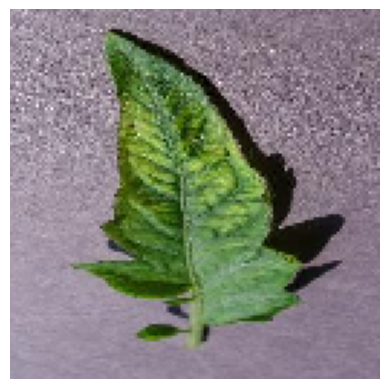

In [41]:
test_image_path = r'C:\Users\POOJA\Downloads\datascience\deep_learnig\cnn\tomato\val\Tomato___Tomato_mosaic_virus\00c07a77-15e6-4815-92d4-8d1e1afb7f3c___PSU_CG 2052.jpg'

if os.path.exists(test_image_path):
    img = tf.keras.utils.load_img(test_image_path, target_size = (img_ht, img_wid))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    
    predictions = model.predict(img_array)
    
    score =  tf.nn.softmax(predictions[0])
    score = predictions[0]
    
    predicted_class = np.argmax(score)
    
    print('predicted class:', class_names[predicted_class])
    print('confidence:', round(100*score[predicted_class], 2),'%')
    
    plt.imshow(img)
    plt.axis('off')
    plt.show()